## Delivery Prediction Model

#### 1. Load the libraries and data

In [69]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import math 
from pathlib import Path
from scipy import stats

from scipy.stats import shapiro
from scipy.stats import levene

In [3]:
raw_data = pd.read_csv(f"{Path.cwd().parent}/data/raw/delivery_data.csv")

### 2.Basic data checks

In [4]:
raw_data.head(10).T

,0,1,2,3,4,5,6,7,8,9
order_id,ORD000001,ORD000002,ORD000003,ORD000004,ORD000005,ORD000006,ORD000007,ORD000008,ORD000009,ORD000010
order_datetime,2026-02-21 22:14:00,2026-02-22 11:23:00,2026-02-11 21:59:00,2026-03-14 16:17:00,2026-01-08 12:13:00,2026-02-03 19:35:00,2026-01-24 19:24:00,2026-03-04 20:50:00,2026-02-02 16:22:00,2026-03-31 16:13:00
restaurant_lat,52.390799,52.400844,52.354236,52.412489,52.356706,52.37739,52.345693,52.388286,52.384484,52.36698
restaurant_lon,4.913966,4.875334,4.899707,4.950663,4.872324,4.946287,4.90837,4.927001,4.920692,4.906373
customer_lat,52.328883,52.343573,52.405568,52.468,52.402671,52.303319,52.28106,52.437114,52.400918,52.353937
customer_lon,4.852045,4.818347,4.845648,4.915494,4.858852,4.891564,4.962765,4.850329,4.880142,4.820949
num_items,3,4,7,5,6,1,1,7,3,5
order_value,47.42,73.59,173.0,59.63,103.76,24.34,8.27,133.48,48.08,57.15
day_of_week,Saturday,Sunday,Wednesday,Saturday,Thursday,Tuesday,Saturday,Wednesday,Monday,Tuesday
hour,22,11,21,16,12,19,19,20,16,16


In [5]:
raw_data.describe()

,restaurant_lat,restaurant_lon,customer_lat,customer_lon,num_items,order_value,hour,distance_km,actual_delivery_time_minutes
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,52.367886,4.904102,52.367675,4.904507,4.019900,66.431822,15.998300,6.236907,49.260100
std,0.028859,0.028875,0.059470,0.059451,1.998575,39.624910,3.715384,2.528933,12.582602
min,52.317641,4.854103,52.230334,4.765289,1.000000,8.010000,10.000000,0.080000,15.000000
25%,52.342721,4.879241,52.322255,4.859433,2.000000,34.667500,13.000000,4.360000,40.000000
50%,52.368536,4.904221,52.367556,4.904540,4.000000,60.395000,16.000000,6.210000,49.000000
75%,52.392529,4.929454,52.413292,4.949347,6.000000,92.860000,19.000000,8.290000,58.000000
max,52.417575,4.954098,52.506120,5.041388,7.000000,174.970000,22.000000,11.670000,91.000000


#### Insights

* max items in an order = 7 , but there are some rational numbers as well in num_items as well.

#### Delivery time and order distribution

Text(0.5, 1.0, 'Average delivery time across the day')

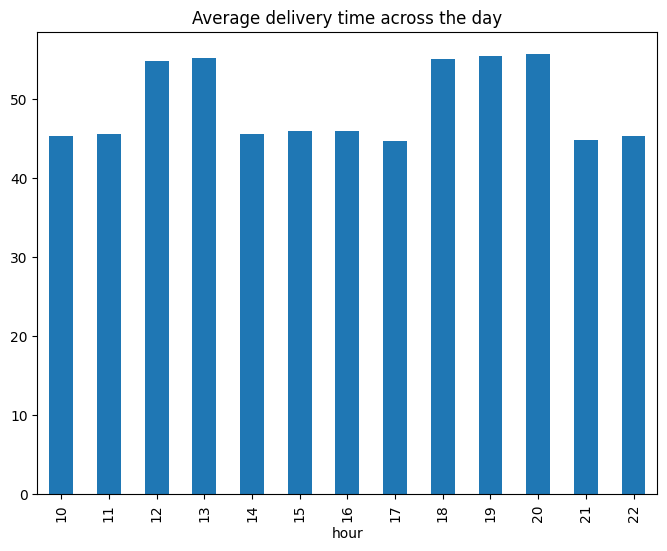

In [79]:
delivery_distribution = raw_data.groupby(['hour'])['actual_delivery_time_minutes'].mean().plot(kind ='bar',figsize = (8,6))
plt.title("Average delivery time across the day")

Text(0.5, 1.0, 'Orders distribution across the day')

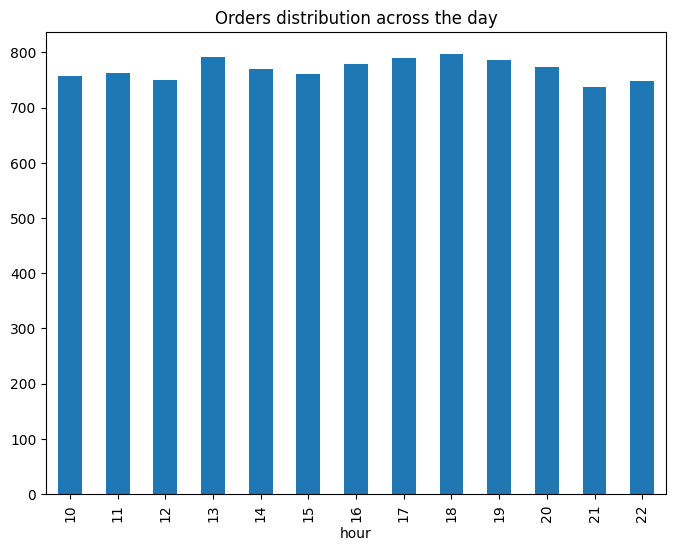

In [80]:
order_distribution = raw_data.groupby(['hour'])['order_id'].nunique().plot(kind='bar', figsize=(8,6))
plt.title("Orders distribution across the day")

#### Checking for nulls and data types

In [6]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   order_id                      10000 non-null  str    
 1   order_datetime                10000 non-null  str    
 2   restaurant_lat                10000 non-null  float64
 3   restaurant_lon                10000 non-null  float64
 4   customer_lat                  10000 non-null  float64
 5   customer_lon                  10000 non-null  float64
 6   num_items                     10000 non-null  int64  
 7   order_value                   10000 non-null  float64
 8   day_of_week                   10000 non-null  str    
 9   hour                          10000 non-null  int64  
 10  is_weekend                    10000 non-null  bool   
 11  weather                       10000 non-null  str    
 12  traffic_level                 10000 non-null  str    
 13  distance_km  

#### Insight

* Found order datetime to be str data type and hence it needs to be converted to datetime

In [7]:
raw_data.duplicated().sum()

np.int64(0)

In [8]:
raw_data['order_datetime'] = pd.to_datetime(raw_data['order_datetime'])

In [9]:
raw_data['order_datetime'].head(10)

0   2026-02-21 22:14:00
1   2026-02-22 11:23:00
2   2026-02-11 21:59:00
3   2026-03-14 16:17:00
4   2026-01-08 12:13:00
5   2026-02-03 19:35:00
6   2026-01-24 19:24:00
7   2026-03-04 20:50:00
8   2026-02-02 16:22:00
9   2026-03-31 16:13:00
Name: order_datetime, dtype: datetime64[us]

#### Understanding the correlation between numerical variables

<Axes: >

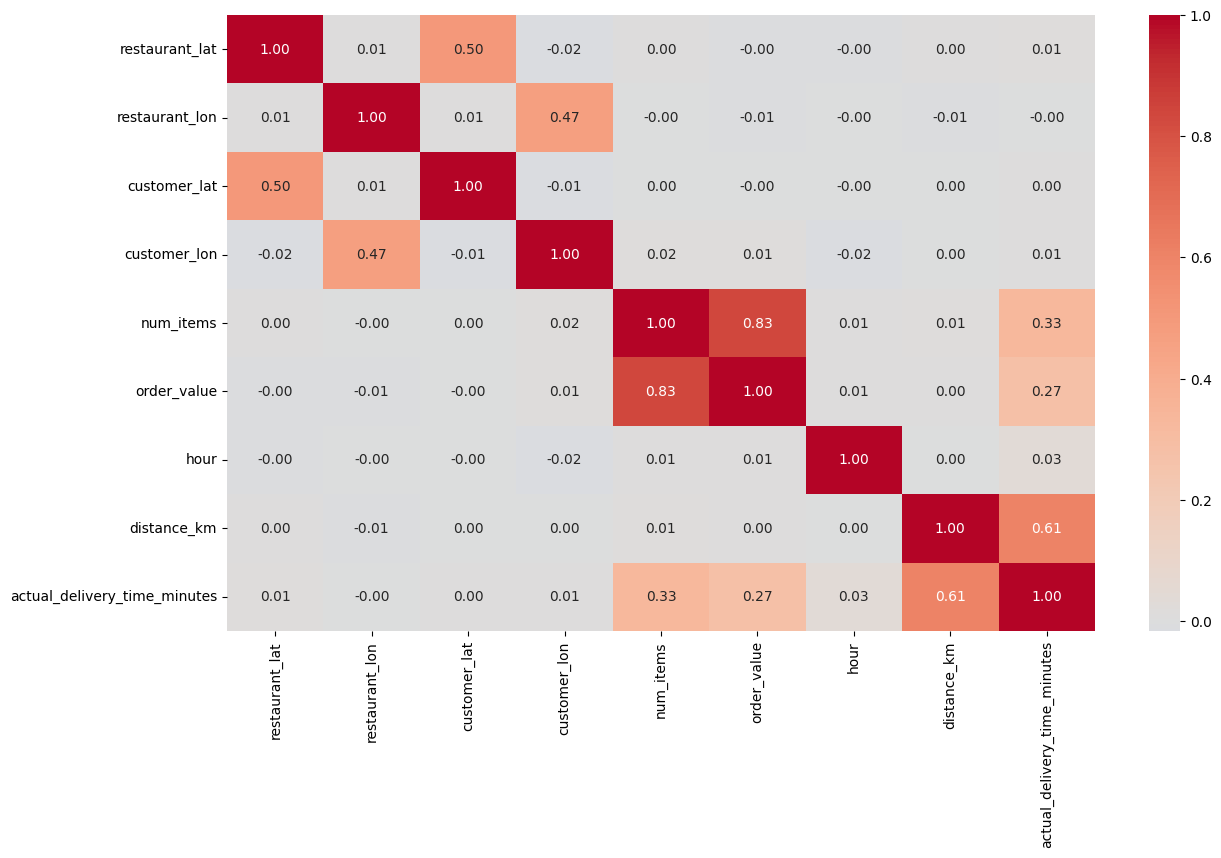

In [25]:
numeric_data = raw_data.select_dtypes(include=[np.number])
corr_matrix = numeric_data.corr()

plt.figure(figsize = (14,8))
sns.heatmap(
    corr_matrix,
    annot= True,
    fmt = ".2f",
    cmap = "coolwarm",
    center = 0
)

In [10]:
print(f"Min date time in dataset : {min(raw_data['order_datetime'])} , Max date time in dataset : {max(raw_data['order_datetime'])}, data days:{(max(raw_data['order_datetime'])-min(raw_data['order_datetime'])).days}")

Min date time in dataset : 2026-01-01 10:16:00 , Max date time in dataset : 2026-03-31 22:59:00, data days:89


#### Creating the list of categorical and continous variables

In [58]:
cat_cols = raw_data.select_dtypes(
    include=['object', 'category', 'bool','str']
).columns.tolist()

categorical_cols = [cols for cols in cat_cols if  cols != 'order_id']

In [62]:
continuous_cols = raw_data.select_dtypes(include = ['int','float']).columns.to_list()

#### Understanding distribution of data across continuous variable


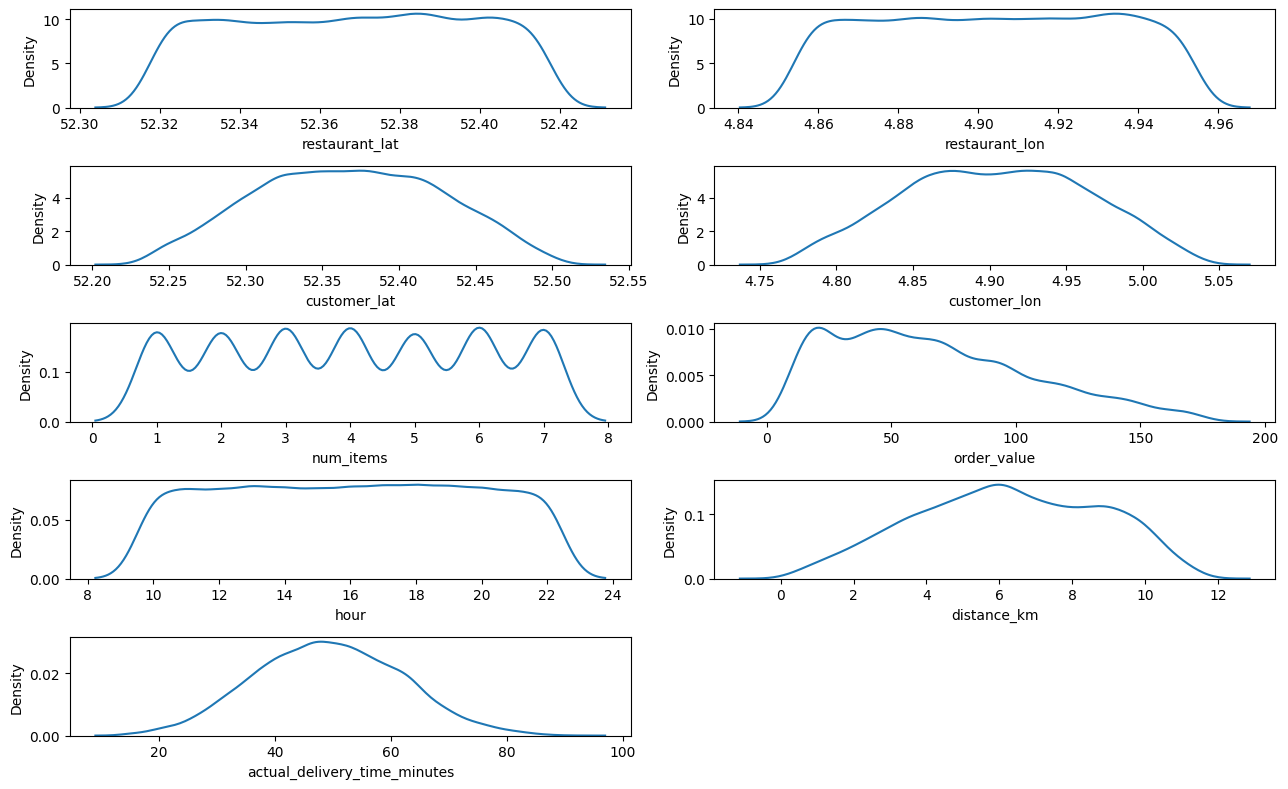

In [63]:
con_num_rows = math.ceil(len(continuous_cols)/2)

fig,axes = plt.subplots(con_num_rows,2,figsize = (13,8))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    sns.kdeplot(data = raw_data, x= col, ax = axes[i])


for j in range(i+1,len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Understanding the distribution of data across categories

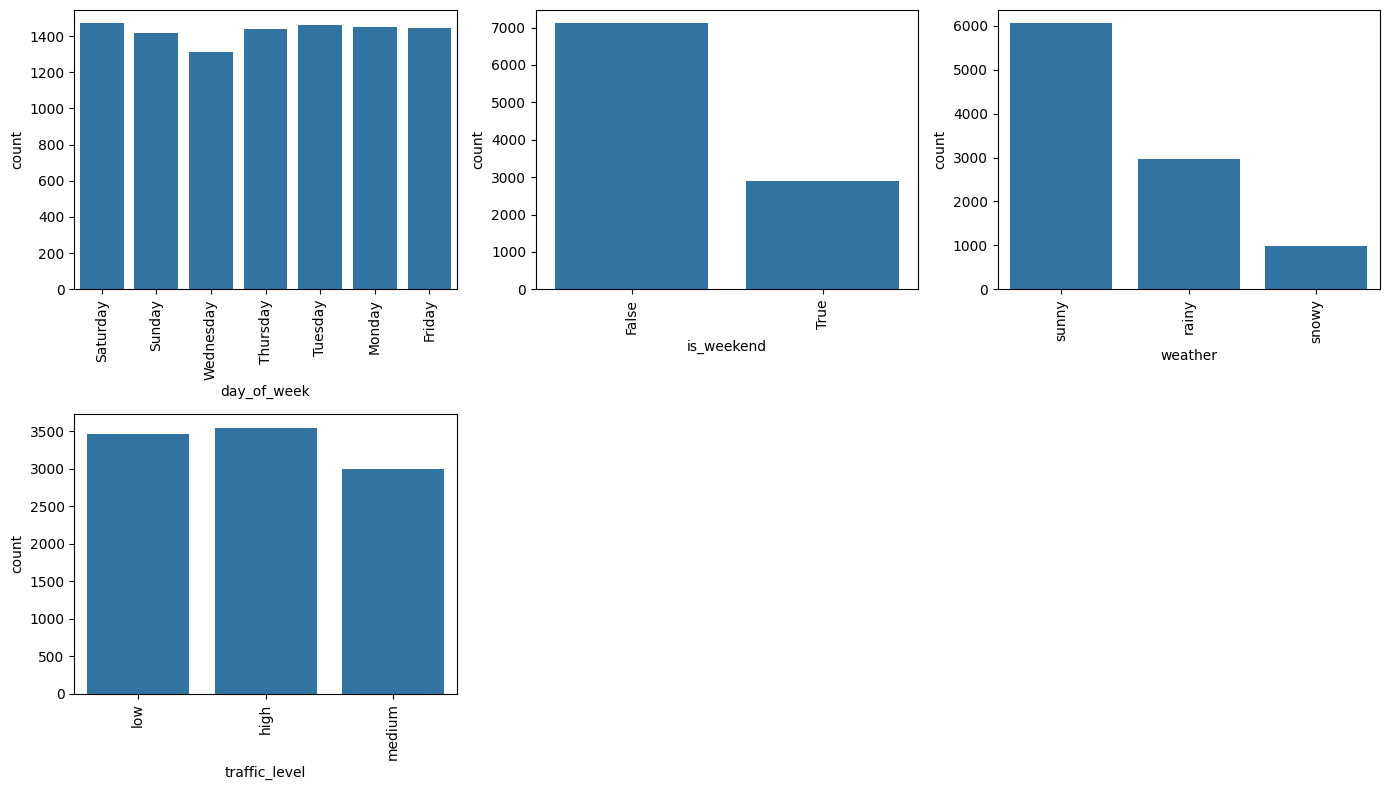

In [64]:
cat_num_rows = math.ceil(len(categorical_cols)/2)

fig,axes = plt.subplots(cat_num_rows,3,figsize = (14,8))

axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data = raw_data,
                  x=col,
                  ax = axes[i]
                  )
    axes[i].tick_params(axis='x', rotation=90)
    
for j in range(i+1,len(axes),1):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

#### Distribution of target variable with respect to categories

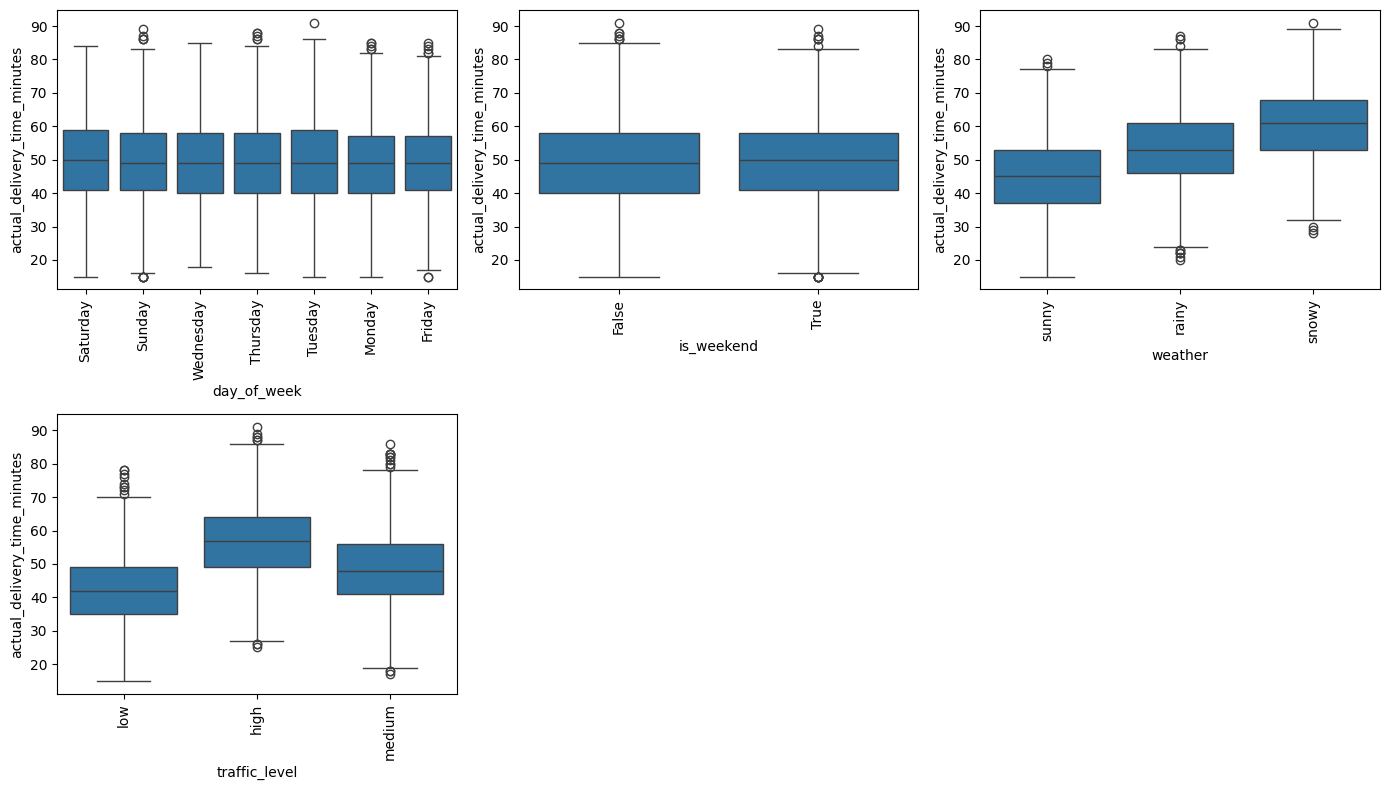

In [65]:
num_rows = math.ceil(len(categorical_cols)/2)

fig, axes = plt.subplots(num_rows,3, figsize = (14,8))
axes = axes.flatten()

for i, cols in enumerate(categorical_cols):
    sns.boxplot(data = raw_data, x= cols, y = 'actual_delivery_time_minutes', ax = axes[i])
    
    axes[i].tick_params(axis = 'x',rotation=90)

for j in range(i+1,len(axes),1):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Insights

* Delivery time is highest for traffic_level = high (normal behaviour)
* Delivery time is consistent across all days
* Delivery time is consistent across weekday and weekend
* Delivery time is higher for snowy day as compared to other days
* To optimize delivery window, weather and traffic are primary drivers of delay

#### Check for Normalcy

Analysis of Q-Q plot for normal distribution check in day_of_week column


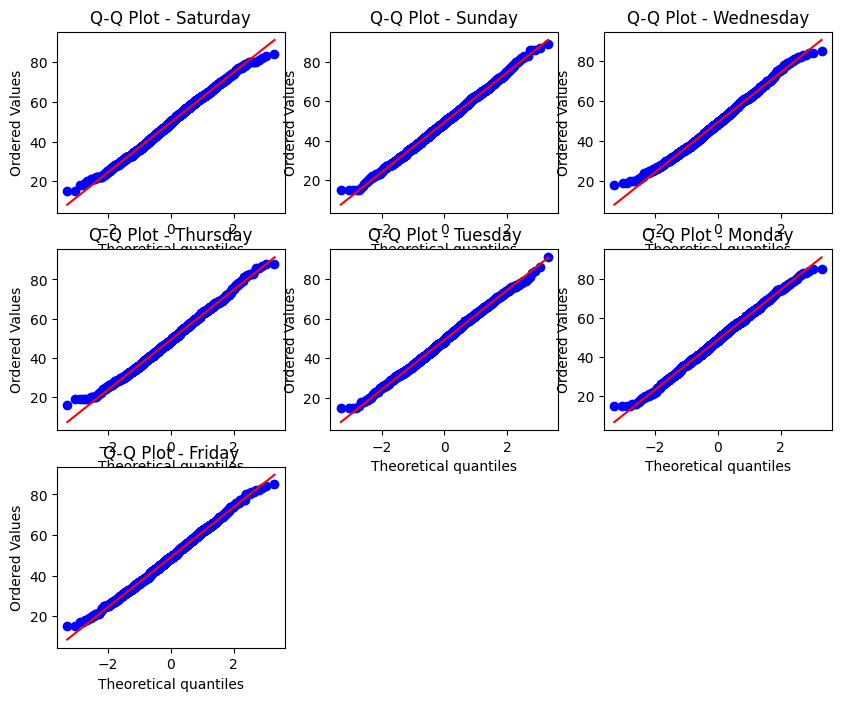

Analysis of Q-Q plot for normal distribution check in is_weekend column


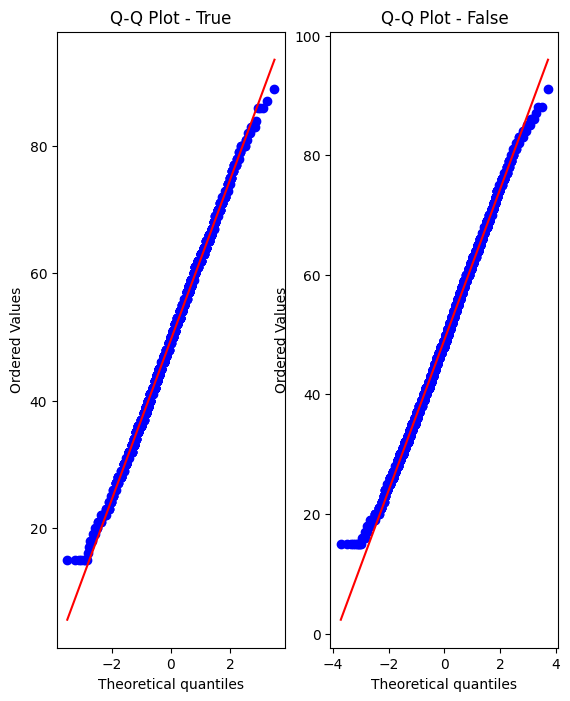

Analysis of Q-Q plot for normal distribution check in weather column


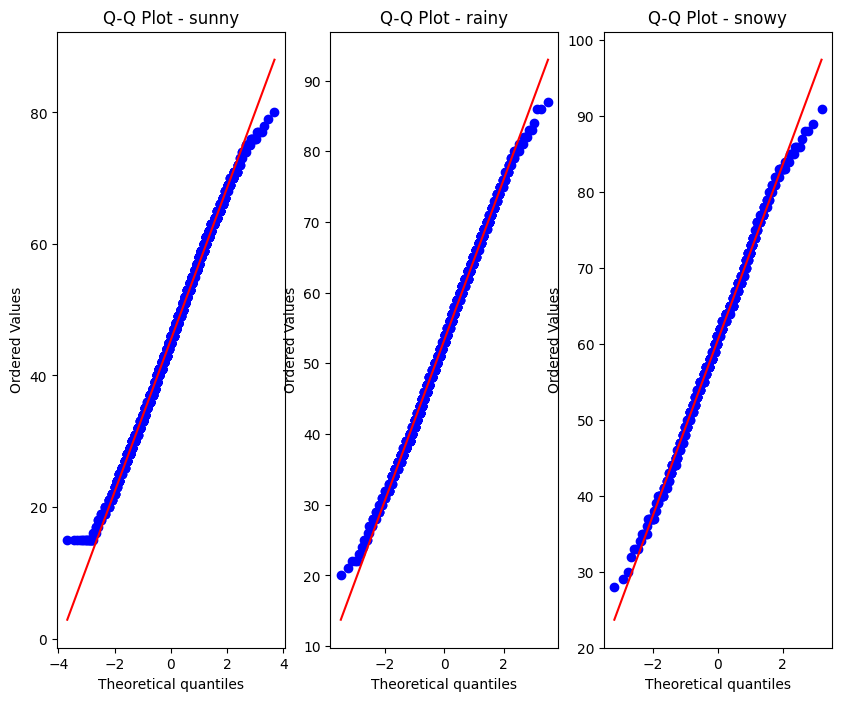

Analysis of Q-Q plot for normal distribution check in traffic_level column


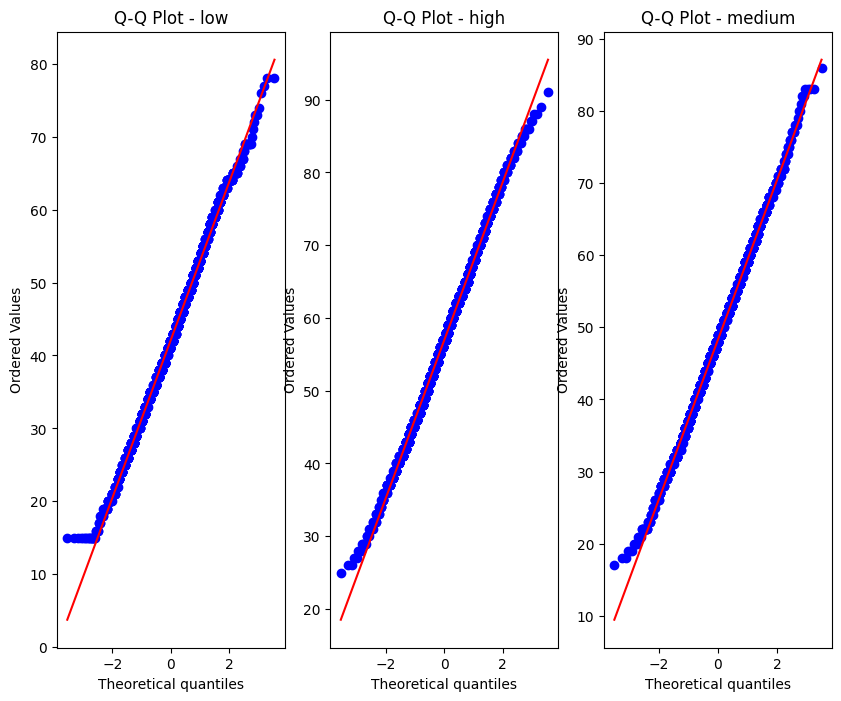

In [66]:

for col in categorical_cols:
    print(f"Analysis of Q-Q plot for normal distribution check in {col} column")
    total_cat = len(raw_data[col].unique())
    num_rows = math.ceil(total_cat/3)

    fig, ax = plt.subplots(num_rows,3,figsize = (10,8))
    ax = ax.flatten()

    for i,sub_cat in enumerate(raw_data[col].unique()):
        stats.probplot(raw_data[raw_data[col]==sub_cat]['actual_delivery_time_minutes'], dist = "norm", plot =ax[i])
        ax[i].set_title(f"Q-Q Plot - {sub_cat}")

    for j in range(i+1,len(ax),1):
        fig.delaxes(ax[j])
    
    plt.show()

#### ANOVA test for testing the significance

In [74]:

for col in categorical_cols:
    groups = [raw_data[raw_data[col] == w]['actual_delivery_time_minutes'] for w in raw_data[col].unique()]

    for g in groups:
        if len(g) < 10:
            print("Warning: Small sample size")

    # The actual ANOVA test
    stat, p = stats.levene(*groups)
    if p < 0.05:
        print(f"LEVENE test Result: Failed- {p} - Do not use ANOVA")
    else:
        print(f"LEVENE test Result: Passed - {p} - Can use ANOVA")
        f_stat, p_val = stats.f_oneway(*groups)
        if p_val < 0.05:
            print(f"ANOVA Result: Significant! {col} affects delivery time.")
        else:
            print(f"ANOVA Result: Not Significant. {col} doesn't seem to matter.")

LEVENE test Result: Passed - 0.814658460635548 - Can use ANOVA
ANOVA Result: Not Significant. day_of_week doesn't seem to matter.
LEVENE test Result: Passed - 0.9326949294652538 - Can use ANOVA
ANOVA Result: Not Significant. is_weekend doesn't seem to matter.
LEVENE test Result: Passed - 0.4955907671523353 - Can use ANOVA
ANOVA Result: Significant! weather affects delivery time.
LEVENE test Result: Passed - 0.6194259411418299 - Can use ANOVA
ANOVA Result: Significant! traffic_level affects delivery time.
